In [1]:
from collections import OrderedDict

import torch
from torch import nn
from timm.models.layers import DropPath
import os,sys
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import pdb
from torch.utils.data import Dataset, DataLoader
import matplotlib.animation as animation

from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.,
                 channel_first=False):

        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.act = act_layer()
        self.drop = nn.Dropout(drop)

        if channel_first:
            self.fc1 = nn.Conv2d(in_features, hidden_features, 1)
            self.fc2 = nn.Conv2d(hidden_features, out_features, 1)
        else:
            self.fc1 = nn.Linear(in_features, hidden_features)
            self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [3]:
class Attention(nn.Module):
    """
    A simplified version of attention from DSTFormer that also considers x tensor to be (B, T, J, C) instead of
    (B * T, J, C)
    """
    
    def __init__(self, dim_in, dim_out, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0.,
                 mode='spatial',vis = 'no'):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim_in // num_heads
        self.scale = qk_scale or head_dim ** -0.5
        self.vis = vis
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim_in, dim_out)
        self.mode = mode
        self.qkv = nn.Linear(dim_in, dim_in * 3, bias=qkv_bias)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, T, J, C = x.shape

        qkv = self.qkv(x).reshape(B, T, J, 3, self.num_heads, C // self.num_heads).permute(3, 0, 4, 1, 2,
                                                                                           5)  # (3, B, H, T, J, C)
        if self.mode == 'temporal':
            q, k, v = qkv[0], qkv[1], qkv[2]
            x = self.forward_temporal(q, k, v)
        elif self.mode == 'spatial':
            q, k, v = qkv[0], qkv[1], qkv[2]
            x = self.forward_spatial(q, k, v)
        else:
            raise NotImplementedError(self.mode)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

    def forward_spatial(self, q, k, v):
        B, H, T, J, C = q.shape
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, T, J, J)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = attn @ v  # (B, H, T, J, C)
        x = x.permute(0, 2, 3, 1, 4).reshape(B, T, J, C * self.num_heads)
        return x  # (B, T, J, C)

    def forward_temporal(self, q, k, v):
        B, H, T, J, C = q.shape
        qt = q.transpose(2, 3)  # (B, H, J, T, C)
        kt = k.transpose(2, 3)  # (B, H, J, T, C)
        vt = v.transpose(2, 3)  # (B, H, J, T, C)

        attn = (qt @ kt.transpose(-2, -1)) * self.scale  # (B, H, J, T, T)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = attn @ vt  # (B, H, J, T, C)
        x = x.permute(0, 3, 2, 1, 4).reshape(B, T, J, C * self.num_heads)
        return x  # (B, T, J, C)

In [4]:
class CrossAttention(nn.Module):

    def __init__(self,dim_in,dim_out,num_heads = 8,qkv_bias = False,qkv_scale = None,attn_drop=0.,proj_drop=0.,
                 mode = 'temporal',back_att = None):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim_in // num_heads
        self.scale = qkv_scale or head_dim**(-0.5)
        self.wq = nn.Linear(dim_in,dim_in,bias=qkv_bias)
        self.wk = nn.Linear(dim_in,dim_in,bias=qkv_bias)
        self.wv = nn.Linear(dim_in,dim_in,bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim_in,dim_out)
        self.proj_drop = nn.Dropout(proj_drop)
        self.mode = mode
        self.back_att = back_att

    def forward(self,q,kv):
        #batch_size temporal_frame_num num_joints feature_dim
        b , t , j , d = q.shape
        t_sup = kv.shape[1]
        q = self.wq(q).reshape(b,t,j,self.num_heads,d//self.num_heads).permute(0,3,2,1,4)
        k = self.wk(kv).reshape(b,t_sup,j,self.num_heads,d//self.num_heads).permute(0,3,2,1,4)
        v = self.wv(kv).reshape(b,t_sup,j,self.num_heads,d//self.num_heads).permute(0,3,2,1,4)

        attn = (q @ k.transpose(-2,-1))*self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn@v  # b h j t c
        out = out.permute(0,3,2,1,4).reshape(b,t,j,d)
        out = self.proj(out)
        out = self.proj_drop(out)
        if self.back_att:
            return attn,out
        else:
            return out

In [5]:
class Sum_Attention(nn.Module):


    def __init__(self, dim_in, dim_out, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0.,
                 mode='spatial'):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim_in // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim_in, dim_out)
        self.mode = mode
        self.qkv = nn.Linear(dim_in, dim_in * 3, bias=qkv_bias)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x,att_map,weight):
        B, T, J, C = x.shape

        qkv = self.qkv(x).reshape(B, T, J, 3, self.num_heads, C // self.num_heads).permute(3, 0, 4, 1, 2,
                                                                                           5)  # (3, B, H, T, J, C)

        q, k, v = qkv[0], qkv[1], qkv[2]
        B, H, T, J, C = q.shape
        qt = q.transpose(2, 3)  # (B, H, J, T, C)
        kt = k.transpose(2, 3)  # (B, H, J, T, C)
        vt = v.transpose(2, 3)  # (B, H, J, T, C)

        attn = (qt @ kt.transpose(-2, -1)) * self.scale  # (B, H, J, T, T)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)


        attn = weight*attn + (1-weight)*att_map

        attn = self.attn_drop(attn)
        x = attn @ vt  # (B, H, J, T, C)
        x = x.permute(0, 3, 2, 1, 4).reshape(B, T, J, C * self.num_heads)

        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [6]:
class MIBlock(nn.Module):


    def __init__(self, dim, mlp_ratio=4., act_layer=nn.GELU, attn_drop=0., drop=0., drop_path=0.,
                 num_heads=8, qkv_bias=False, qk_scale=None, use_layer_scale=True, layer_scale_init_value=1e-5,
                 mode='temporal', mixer_type="attention", use_temporal_similarity=True,
                 temporal_connection_len=1, neighbour_num=4, n_frames=243,is_local = None):
        super().__init__()
        self.norm_full = nn.LayerNorm(dim)
        self.norm_center = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim*mlp_ratio)
        self.full_center = CrossAttention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode,back_att=True)
        self.center_full = CrossAttention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode,back_att=True)
        self.mlp_1 = MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)
        self.mlp_2 = MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)
        self.norm_1 = nn.LayerNorm(dim)
        self.norm_2 = nn.LayerNorm(dim)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.use_layer_scale = use_layer_scale
        if use_layer_scale:
            self.layer_scale_1 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_2 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_3 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_4 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_5 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_6 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_7 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_8 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)


        self.norm_sa_self = nn.LayerNorm(dim)
        self.map_sa_self = Attention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode)
        self.norm_mlp_self = nn.LayerNorm(dim)
        self.mlp_sa_self = MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)

        self.norm_sa_1 = nn.LayerNorm(dim)
        self.map_sum = Sum_Attention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode)
        self.norm_sa_2 = nn.LayerNorm(dim)
        self.mlp_sa = MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)

        
        self.sg = nn.Sigmoid()
        self.att_weight = nn.Parameter(torch.rand(1))

    def forward(self, x,pose_query):
        """
        x: tensor with shape [B, T, J, C]
        """
        if self.use_layer_scale:

            attn_map_1,out_1 = self.center_full(self.norm_center(pose_query),self.norm_full(x))
            pose_query = pose_query + self.drop_path(self.layer_scale_1.unsqueeze(0).unsqueeze(0)*out_1)
            pose_query = pose_query + self.drop_path(self.layer_scale_2.unsqueeze(0).unsqueeze(0)*self.mlp_1(self.norm_1(pose_query)))

            attn_map_2,out_2 = self.full_center(self.norm_full(x),self.norm_center(pose_query))
            x = x + self.drop_path(self.layer_scale_3.unsqueeze(0).unsqueeze(0)*out_2)
            x = x + self.drop_path(self.layer_scale_4.unsqueeze(0).unsqueeze(0)*self.mlp_2(self.norm_2(x)))

            attn_map = attn_map_2 @ attn_map_1

            norm_weight = self.sg(self.att_weight)

            x = x + self.drop_path(self.layer_scale_7.unsqueeze(0).unsqueeze(1)*self.map_sa_self(self.norm_sa_self(x)))
            x = x + self.drop_path(self.layer_scale_8.unsqueeze(0).unsqueeze(1)*self.mlp_sa_self(self.norm_mlp_self(x)))

            x = x + self.drop_path(self.layer_scale_5.unsqueeze(0).unsqueeze(1)*self.map_sum(self.norm_sa_1(x),attn_map,norm_weight))
            x = x + self.drop_path(self.layer_scale_6.unsqueeze(0).unsqueeze(1)*self.mlp_sa(self.norm_sa_2(x)))

        return x,pose_query

In [7]:
class TransBlock(nn.Module):


    def __init__(self, dim, mlp_ratio=4., act_layer=nn.GELU, attn_drop=0., drop=0., drop_path=0.,
                 num_heads=8, qkv_bias=False, qk_scale=None, use_layer_scale=True, layer_scale_init_value=1e-5,
                 mode='spatial', mixer_type="attention", use_temporal_similarity=True,
                 temporal_connection_len=1, neighbour_num=4, n_frames=243):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.mixer_type = mixer_type
        if mixer_type == 'crossattention': 
            self.local_attention_list = nn.ModuleList([
                Attention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode) for i in range(3)
            ])
            mlp_hidden_dim = int(dim * mlp_ratio)
            self.loacl_mlps =  nn.ModuleList([
                MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop) for i in range(3)
            ])
            self.len = 0
            self.normq = nn.LayerNorm(dim)
            self.normkv = nn.LayerNorm(dim)
            self.mixer = nn.ModuleList([
                CrossAttention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode),
                CrossAttention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode),
                CrossAttention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode),
            ])
            self.self_attention = Attention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode,vis='yes')
            self.mlps = nn.ModuleList([
                MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop),
                MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop),
                MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)
            ])
            self.sa_mlp = MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop)
            self.norms = nn.ModuleList([
                nn.LayerNorm(dim),
                nn.LayerNorm(dim),
                nn.LayerNorm(dim)
            ])
        elif mixer_type == 'attention':
            self.mixer = Attention(dim, dim, num_heads, qkv_bias, qk_scale, attn_drop,
                                   proj_drop=drop, mode=mode)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim,
                       act_layer=act_layer, drop=drop)


        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.use_layer_scale = use_layer_scale
        if use_layer_scale:
            self.layer_scale_1 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
            self.layer_scale_2 = nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)

    def forward(self, x):
        """
        x: tensor with shape [B, T, J, C]
        """

        if self.mixer_type == 'crossattention':
            x = self.forward_local(x)
            self.len = x.shape[1] // 3
            x = self.forward_cross(x,self.len)
            return x
        if self.use_layer_scale:
            x = x + self.drop_path(
                self.layer_scale_1.unsqueeze(0).unsqueeze(0)
                * self.mixer(self.norm1(x)))
            x = x + self.drop_path(
                self.layer_scale_2.unsqueeze(0).unsqueeze(0)
                * self.mlp(self.norm2(x)))
        else:
            x = x + self.drop_path(self.mixer(self.norm1(x)))
            x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x
    
    def forward_cross(self,x,len):
        part_size = len
        first_part = x[:,:part_size]
        middel_part = x[:,part_size:2*part_size]
        last_part = x[:,2*part_size:]
        q = []
        kv = []
        q.append(first_part)
        q.append(middel_part)
        q.append(last_part)
        kv.append(torch.cat([middel_part,last_part],dim=1))
        kv.append(torch.cat([first_part,last_part],dim=1))
        kv.append(torch.cat([middel_part,last_part],dim=1))

        for i in range(3):
            if self.use_layer_scale:
                q[i] = q[i] + self.drop_path(self.layer_scale_1.unsqueeze(0).unsqueeze(0)*self.mixer[i](self.normq(q[i]),self.normkv(kv[i])))
                q[i] = q[i] + self.drop_path(self.layer_scale_1.unsqueeze(0).unsqueeze(0)*self.mlps[i](self.norms[i](q[i])))

            else:
                q[i] = q[i] + self.drop_path(self.mixer[i](self.normq(q[i]),self.normkv(kv[i])))
                q[i] = q[i] + self.drop_path(self.mlps[i](self.norms[i](q[i])))

        out = torch.cat(q,dim=1)
        if self.use_layer_scale:
            out = out + self.drop_path(
                self.layer_scale_1.unsqueeze(0).unsqueeze(0)
                * self.self_attention(self.norm1(out)))
            out = out + self.drop_path(
                self.layer_scale_2.unsqueeze(0).unsqueeze(0)
                * self.sa_mlp(self.norm2(out)))
        else:
            out = out + self.drop_path(self.self_attention(self.norm1(out)))
            out = out + self.drop_path(self.sa_mlp(self.norm2(out)))

        return out

    def forward_local(self,x):
        x = list(torch.chunk(x,3,dim=1))

        for i in range(3):
            if self.use_layer_scale:
                x[i] = x[i] + self.drop_path(
                    self.layer_scale_1.unsqueeze(0).unsqueeze(0)
                    * self.local_attention_list[i](self.norm1(x[i])))
                x[i] = x[i] + self.drop_path(
                    self.layer_scale_2.unsqueeze(0).unsqueeze(0)
                    * self.loacl_mlps[i](self.norm2(x[i])))
            else:
                x[i] = x[i] + self.drop_path(self.local_attention_list[i](self.norm1(x[i])))
                x[i] = x[i] + self.drop_path(self.loacl_mlps[i](self.norm2(x[i])))

        out = torch.cat(x,dim=1)
        return out


class DSTFormerBlock(nn.Module):


    def __init__(self, dim, mlp_ratio=4., act_layer=nn.GELU, attn_drop=0., drop=0., drop_path=0.,
                 num_heads=8, use_layer_scale=True, qkv_bias=False, qk_scale=None, layer_scale_init_value=1e-5,
                 use_adaptive_fusion=True, hierarchical=False, use_temporal_similarity=True,
                 temporal_connection_len=1, use_tcn=False, graph_only=False, neighbour_num=4, n_frames=243):
        super().__init__()
        self.hierarchical = hierarchical
        dim = dim // 2 if hierarchical else dim


        self.att_spatial = TransBlock(dim, mlp_ratio, act_layer, attn_drop, drop, drop_path, num_heads, qkv_bias,
                                         qk_scale, use_layer_scale, layer_scale_init_value,
                                         mode='spatial', mixer_type="attention",
                                         use_temporal_similarity=use_temporal_similarity,
                                         neighbour_num=neighbour_num,
                                         n_frames=n_frames)
        self.att_temporal = TransBlock(dim, mlp_ratio, act_layer, attn_drop, drop, drop_path, num_heads, qkv_bias,
                                          qk_scale, use_layer_scale, layer_scale_init_value,
                                          mode='temporal', mixer_type="attention",
                                          use_temporal_similarity=use_temporal_similarity,
                                          neighbour_num=neighbour_num,
                                          n_frames=n_frames)



        self.graph_spatial = TransBlock(dim, mlp_ratio, act_layer, attn_drop, drop, drop_path, num_heads,
                                               qkv_bias,
                                               qk_scale, use_layer_scale, layer_scale_init_value,
                                               mode='temporal', mixer_type="attention",
                                               use_temporal_similarity=use_temporal_similarity,
                                               temporal_connection_len=temporal_connection_len,
                                               neighbour_num=neighbour_num,
                                               n_frames=n_frames)
        self.graph_temporal = TransBlock(dim, mlp_ratio, act_layer, attn_drop, drop, drop_path, num_heads,
                                                qkv_bias,
                                                qk_scale, use_layer_scale, layer_scale_init_value,
                                                mode='spatial', mixer_type='attention',
                                                use_temporal_similarity=use_temporal_similarity,
                                                temporal_connection_len=temporal_connection_len,
                                                neighbour_num=neighbour_num,
                                                n_frames=n_frames)

        self.use_adaptive_fusion = use_adaptive_fusion
        if self.use_adaptive_fusion:
            self.fusion = nn.Linear(dim * 2, 2)
            self._init_fusion()

    def _init_fusion(self):
        self.fusion.weight.data.fill_(0)
        self.fusion.bias.data.fill_(0.5)

    def forward(self, x):
        """
        x: tensor with shape [B, T, J, C]
        """

        x_attn = self.att_temporal(self.att_spatial(x))
        x_graph = self.graph_temporal(self.graph_spatial(x))


        alpha = torch.cat((x_attn, x_graph), dim=-1)
        alpha = self.fusion(alpha)
        alpha = alpha.softmax(dim=-1)
        x = x_attn * alpha[..., 0:1] + x_graph * alpha[..., 1:2]

        return x


class MemoryInducedBlock(nn.Module):

    def __init__(self, dim, mlp_ratio=4., act_layer=nn.GELU, attn_drop=0., drop=0., drop_path=0.,
                 num_heads=8, use_layer_scale=True, qkv_bias=False, qk_scale=None, layer_scale_init_value=1e-5,
                 use_adaptive_fusion=True, hierarchical=False, use_temporal_similarity=True,
                 temporal_connection_len=1, use_tcn=False, graph_only=False, neighbour_num=4, n_frames=243,mode='temporal'):
        super().__init__()
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.local_attention_list = nn.ModuleList([
                Attention(dim,dim,num_heads,qkv_bias,qk_scale,attn_drop,proj_drop=drop,mode=mode) for i in range(3)
            ])
        self.loacl_mlps =  nn.ModuleList([
                MLP(in_features=dim,hidden_features=mlp_hidden_dim,act_layer=act_layer,drop=drop) for i in range(3)
            ])
        self.layer_scale =[
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True),
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True),
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True),
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True),
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True),
            nn.Parameter(layer_scale_init_value * torch.ones(dim), requires_grad=True)
        ]
        for i in range(len(self.layer_scale)):
            self.layer_scale[i] = self.layer_scale[i].to('cuda')
        self.local_norms = nn.ModuleList([
            nn.LayerNorm(dim),
            nn.LayerNorm(dim),
            nn.LayerNorm(dim),
            nn.LayerNorm(dim),
            nn.LayerNorm(dim),
            nn.LayerNorm(dim)
        ])

        self.cross_temporal = MIBlock(dim, mlp_ratio, act_layer, attn_drop, drop, drop_path, num_heads, qkv_bias,
                                          qk_scale, use_layer_scale, layer_scale_init_value,
                                          mode='temporal', mixer_type="attention",
                                          use_temporal_similarity=use_temporal_similarity,
                                          neighbour_num=neighbour_num,
                                          n_frames=n_frames)      

    def forward(self, x,pose_query):
        """
        x: tensor with shape [B, T, J, C]
        """
        x = list(torch.chunk(x,3,dim=1))

        for i in range(3):
            x[i] = x[i] + self.drop_path(self.layer_scale[i].unsqueeze(0).unsqueeze(0) * self.local_attention_list[i](self.local_norms[i](x[i])))
            x[i] = x[i] + self.drop_path(self.layer_scale[i+3].unsqueeze(0).unsqueeze(0) * self.loacl_mlps[i](self.local_norms[i+3](x[i])))

        x = torch.cat(x,dim=1)

        x,pose_query = self.cross_temporal(x,pose_query)

        return x,pose_query

def create_layers(dim, n_layers, mlp_ratio=4., act_layer=nn.GELU, attn_drop=0., drop_rate=0., drop_path_rate=0.,
                  num_heads=8, use_layer_scale=True, qkv_bias=False, qkv_scale=None, layer_scale_init_value=1e-5,
                  use_adaptive_fusion=True, hierarchical=False, use_temporal_similarity=True,
                  temporal_connection_len=1, use_tcn=False, graph_only=False, neighbour_num=4, n_frames=243,type = None):

    layers = []
    for _ in range(n_layers):
        if type == 'temporal':
            layers.append(MemoryInducedBlock(dim=dim,
                                          mlp_ratio=mlp_ratio,
                                          act_layer=act_layer,
                                          attn_drop=attn_drop,
                                          drop=drop_rate,
                                          drop_path=drop_path_rate,
                                          num_heads=num_heads,
                                          use_layer_scale=use_layer_scale,
                                          layer_scale_init_value=layer_scale_init_value,
                                          qkv_bias=qkv_bias,
                                          qk_scale=qkv_scale,
                                          use_adaptive_fusion=use_adaptive_fusion,
                                          hierarchical=hierarchical,
                                          use_temporal_similarity=use_temporal_similarity,
                                          temporal_connection_len=temporal_connection_len,
                                          use_tcn=use_tcn,
                                          graph_only=graph_only,
                                          neighbour_num=neighbour_num,
                                          n_frames=n_frames))
        else:
            layers.append(DSTFormerBlock(dim=dim,
                                          mlp_ratio=mlp_ratio,
                                          act_layer=act_layer,
                                          attn_drop=attn_drop,
                                          drop=drop_rate,
                                          drop_path=drop_path_rate,
                                          num_heads=num_heads,
                                          use_layer_scale=use_layer_scale,
                                          layer_scale_init_value=layer_scale_init_value,
                                          qkv_bias=qkv_bias,
                                          qk_scale=qkv_scale,
                                          use_adaptive_fusion=use_adaptive_fusion,
                                          hierarchical=hierarchical,
                                          use_temporal_similarity=use_temporal_similarity,
                                          temporal_connection_len=temporal_connection_len,
                                          use_tcn=use_tcn,
                                          graph_only=graph_only,
                                          neighbour_num=neighbour_num,
                                          n_frames=n_frames))
    layers = nn.Sequential(*layers)

    return layers

class MemoryInducedTransformer(nn.Module):

    def __init__(self, n_layers, dim_in, dim_feat, dim_rep=512, dim_out=3, mlp_ratio=4, act_layer=nn.GELU, attn_drop=0.,
                 drop=0., drop_path=0., use_layer_scale=True, layer_scale_init_value=1e-5, use_adaptive_fusion=True,
                 num_heads=4, qkv_bias=False, qkv_scale=None, hierarchical=False, num_joints=17,
                 use_temporal_similarity=True, temporal_connection_len=1, use_tcn=False, graph_only=False,
                 neighbour_num=4, n_frames=243):

        super().__init__()

        self.joints_embed = nn.Linear(dim_in, dim_feat)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_joints, dim_feat))
        self.norm = nn.LayerNorm(dim_feat)
        self.layers_num = n_layers
        self.layers = create_layers(dim=dim_feat,
                                    n_layers=n_layers,
                                    mlp_ratio=mlp_ratio,
                                    act_layer=act_layer,
                                    attn_drop=attn_drop,
                                    drop_rate=drop,
                                    drop_path_rate=drop_path,
                                    num_heads=num_heads,
                                    use_layer_scale=use_layer_scale,
                                    qkv_bias=qkv_bias,
                                    qkv_scale=qkv_scale,
                                    layer_scale_init_value=layer_scale_init_value,
                                    use_adaptive_fusion=use_adaptive_fusion,
                                    hierarchical=hierarchical,
                                    use_temporal_similarity=use_temporal_similarity,
                                    temporal_connection_len=temporal_connection_len,
                                    use_tcn=use_tcn,
                                    graph_only=graph_only,
                                    neighbour_num=neighbour_num,
                                    n_frames=n_frames)

        self.rep_logit = nn.Sequential(OrderedDict([
            ('fc', nn.Linear(dim_feat, dim_rep)),
            ('act', nn.Tanh())
        ]))

        self.head = nn.Linear(dim_rep, dim_out)

        self.temporal_layers = create_layers(dim=dim_feat,
                                    n_layers=n_layers,
                                    mlp_ratio=mlp_ratio,
                                    act_layer=act_layer,
                                    attn_drop=attn_drop,
                                    drop_rate=drop,
                                    drop_path_rate=drop_path,
                                    num_heads=num_heads,
                                    use_layer_scale=use_layer_scale,
                                    qkv_bias=qkv_bias,
                                    qkv_scale=qkv_scale,
                                    layer_scale_init_value=layer_scale_init_value,
                                    use_adaptive_fusion=use_adaptive_fusion,
                                    hierarchical=hierarchical,
                                    use_temporal_similarity=use_temporal_similarity,
                                    temporal_connection_len=temporal_connection_len,
                                    use_tcn=use_tcn,
                                    graph_only=graph_only,
                                    neighbour_num=neighbour_num,
                                    n_frames=n_frames,
                                    type='temporal')
        

        self.center_pose = nn.Parameter(torch.randn(int(n_frames/3),num_joints,dim_feat))
        self.center_pos_embed = nn.Parameter(torch.zeros(1, num_joints, dim_feat))

    def forward(self, x, return_rep=False):
        """
        :param x: tensor with shape [B, T, J, C] (T=243, J=17, C=3)
        """
        b,t,j,c = x.shape
        pose_query = self.center_pose.unsqueeze(0).repeat(b,1,1,1)
        pose_query = pose_query + self.center_pos_embed
        x = self.joints_embed(x)  #
        x = x + self.pos_embed

        for layer,temporal_layer in zip(self.layers,self.temporal_layers):
            x = layer(x)
            x,pose_query = temporal_layer(x,pose_query)


        x = self.norm(x)
        x = self.rep_logit(x)
        if return_rep:
            return x

        x = self.head(x)

        return x

In [8]:
b, c, t, j = 1, 3, 81, 17
random_x = torch.randn((b, t, j, c)).to('cuda')

model = MemoryInducedTransformer(n_layers=16, dim_in=3, dim_feat=128, mlp_ratio=4, hierarchical=False,
                       use_tcn=False, graph_only=False, n_frames=t).to('cuda')
model.eval()
ckpt_path = '/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d/dataset/dataset/model_params/TCPFormer_ap3d_81.pth.tr'
state_dict = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
new_state_dict = OrderedDict()
model_state_dict = state_dict['model'] if 'model' in state_dict else state_dict
for k, v in model_state_dict.items():
    name = k[7:] if k.startswith('module.') else k  # remove 'module.' prefix
    new_state_dict[name] = v
model.load_state_dict(new_state_dict)

model_params = 0
for parameter in model.parameters():
    model_params = model_params + parameter.numel()
print(f"Model parameter #: {model_params:,}")
out = model(random_x)

Model parameter #: 35,000,755


In [9]:
def read_pkl(data_url):
    file = open(data_url, 'rb')
    content = pickle.load(file)
    file.close()
    return content

def resample(ori_len, target_len, replay=False, randomness=True):
    """Adapted from https://github.com/Walter0807/MotionBERT/blob/main/lib/utils/utils_data.py#L68"""
    if replay:
        if ori_len > target_len:
            st = np.random.randint(ori_len - target_len)
            return range(st, st + target_len)  # Random clipping from sequence
        else:
            return np.array(range(target_len)) % ori_len  # Replay padding
    else:
        if randomness:
            even = np.linspace(0, ori_len, num=target_len, endpoint=False)
            if ori_len < target_len:
                low = np.floor(even)
                high = np.ceil(even)
                sel = np.random.randint(2, size=even.shape)
                result = np.sort(sel * low + (1 - sel) * high)
            else:
                interval = even[1] - even[0]
                result = np.random.random(even.shape) * interval + even
            result = np.clip(result, a_min=0, a_max=ori_len - 1).astype(np.uint32)
        else:
            result = np.linspace(0, ori_len, num=target_len, endpoint=False, dtype=int)
        return result

def split_clips(vid_list, n_frames, data_stride):
    result = []
    st = 0
    i = 0
    
    while i < len(vid_list):
        # Find the boundaries of the current video
        video_start = i
        current_vid_id = vid_list[video_start]
        
        # Advance i to the end of this specific video
        while i < len(vid_list) and vid_list[i] == current_vid_id:
            i += 1
        video_end = i # i is now the start of the NEXT video
        
        video_len = video_end - video_start
        
        if video_len <= n_frames:
            # Case A: Video is shorter than or equal to n_frames -> Resample to fit
            resampled = resample(video_len, n_frames) + video_start
            result.append(resampled)
        else:
            # Case B: Video is longer than n_frames -> Use sliding window
            curr_st = video_start
            while curr_st + n_frames <= video_end:
                result.append(range(curr_st, curr_st + n_frames))
                curr_st += data_stride
            
            # Case C: Handle the "Trailing" frames 
            # If there are frames left that didn't form a full window
            last_possible_start = video_end - n_frames
            if curr_st < video_end and (curr_st - data_stride) != last_possible_start:
                # Add one last clip that ends exactly at the video_end
                result.append(range(last_possible_start, video_end))

    print(f"Split into {len(result)} clips.")
    return result

class DataReaderH36M(Dataset):
    def __init__(self, n_frames, sample_stride, data_stride, read_confidence=True,
                 dt_root='data/motion3d', split='train'):
        self.gt_set = None
        self.split_id = None
        self.test_hw = None
        file_name = f'{split}.pkl'
        
        self.data_raw = read_pkl('%s/%s' % (dt_root, file_name))
        self.dt_dataset = self.preprocess(self.data_raw)
        
        self.n_frames = n_frames
        self.sample_stride = sample_stride
        self.data_stride = data_stride
        self.read_confidence = read_confidence
        
        # Lấy dữ liệu đã được cắt thành clip
        (self.data, self.labels, self.names, self.frames, 
         self.subjects, self.test_hw, self.cam_params, self.gt_3d_cam_sliced) = self.get_sliced_data()

    def preprocess(self, dataset):
        # Mở rộng split_info để lưu trữ thông số camera phục vụ cho back-projection
        split_info = {
            'joint_2d':[], 'joint3d_image':[], 'camera_name':[], 'source':[],
            'video_w':[], 'video_h':[], 'joints_2.5d_image':[], '2.5d_factor':[],
            'action':[], 'name':[], 'frame_index':[], 'subject':[],
            'box': [], 'root_depth': [], 'rotation': [],
            'cx': [], 'cy': [], 'fx': [], 'fy': [],
            'gt_3d_camera': []
        }

        for i in range(len(dataset)):
            dict_i = dataset[i]
            split_info['joint_2d'].append(dict_i['joint_3d_image'])
            split_info['joint3d_image'].append(dict_i['joint_3d_image'])
            split_info['camera_name'].append(dict_i['cameraid'])
            split_info['source'].append(dict_i['videoid'])
            split_info['video_w'].append(dict_i['video_width'])
            split_info['video_h'].append(dict_i['video_height'])
            split_info['2.5d_factor'].append(1/dict_i['ratio'])
            split_info['joints_2.5d_image'].append(np.array(dict_i['joint_3d_image'])/ dict_i['ratio'])
            split_info['action'].append(dict_i['action'])
            split_info['name'].append(dict_i['name'])
            split_info['frame_index'].append(dict_i['frame_index'])
            split_info['subject'].append(dict_i['subject'])
            
            split_info['box'].append(dict_i['box'])
            split_info['root_depth'].append(dict_i['root_depth'])
            split_info['rotation'].append(dict_i['rotation'])
            split_info['cx'].append(dict_i['camera_param']['cx'])
            split_info['cy'].append(dict_i['camera_param']['cy'])
            split_info['fx'].append(dict_i['camera_param']['fx'])
            split_info['fy'].append(dict_i['camera_param']['fy'])
            split_info['gt_3d_camera'].append(dict_i['joint_3d_camera'])
            
        return split_info
        
    def read_2d(self):
        set2d = np.array(self.dt_dataset['joint_2d'], dtype=np.float32)[::self.sample_stride, :, :2]  
        for idx, camera_name in enumerate(self.dt_dataset['camera_name']):
            res_w, res_h = self.dt_dataset['video_w'][idx], self.dt_dataset['video_h'][idx]
            set2d[idx, :, :] = set2d[idx, :, :] / res_w * 2 - [1, res_h / res_w]
            
        if self.read_confidence:
            confidence = np.ones(set2d.shape)[:, :, 0:1] # Giả lập conf = 1 nếu không có
            set2d = np.concatenate((set2d, confidence), axis=2) 
        return set2d

    def read_3d(self):
        labels = np.array(self.dt_dataset['joint3d_image'], dtype=np.float32)[::self.sample_stride, :, :3]
        for idx, camera_name in enumerate(self.dt_dataset['camera_name']):
            res_w, res_h = self.dt_dataset['video_w'][idx], self.dt_dataset['video_h'][idx]
            labels[idx, :, :2] = labels[idx, :, :2] / res_w * 2 - [1, res_h / res_w]
            labels[idx, :, 2:] = labels[idx, :, 2:] / res_w * 2
        return labels
    
    def video_frame(self):
        names = self.dt_dataset['name'][::self.sample_stride]
        frames = self.dt_dataset['frame_index'][::self.sample_stride]
        subjects = self.dt_dataset['subject'][::self.sample_stride]
        return names, frames, subjects

    def read_hw(self):
        if self.test_hw is not None:
            return self.test_hw
        test_hw = np.zeros((len(self.dt_dataset['camera_name']), 2))
        for idx, camera_name in enumerate(self.dt_dataset['camera_name']):
            test_hw[idx] = self.dt_dataset['video_w'][idx], self.dt_dataset['video_h'][idx]
        self.test_hw = test_hw
        return test_hw

    def get_split_id(self):
        if self.split_id is not None:
            return self.split_id
        vid_list = self.dt_dataset['source'][::self.sample_stride]
        self.split_id = split_clips(vid_list, self.n_frames, data_stride=self.data_stride)
        return self.split_id

    def turn_into_test_clips(self, data):
        split_id = self.get_split_id()
        return data[split_id]

    def get_hw(self):
        test_hw = self.read_hw() 
        test_hw = self.turn_into_test_clips(test_hw)[:, 0, :]  
        return test_hw
        
    def get_camera_params(self):
        """Đọc và chuyển đổi các tham số camera thành mảng numpy để dễ slice"""
        keys = ['box', 'root_depth', 'rotation', 'cx', 'cy', 'fx', 'fy']
        params = {k: np.array(self.dt_dataset[k])[::self.sample_stride] for k in keys}
        return params

    def get_sliced_data(self):
        data = self.read_2d() 
        labels = self.read_3d()  
        names, frames, subjects = self.video_frame()
        split_id = self.get_split_id()
        
        data = data[split_id]  
        labels = labels[split_id]
        test_hw = self.get_hw()
        
        names = [names[tup_range[0]] for tup_range in split_id]
        frames = [[frames[idx] for idx in tup_range] for tup_range in split_id]
        subjects = [subjects[tup_range[0]] for tup_range in split_id]
        
        # Slice camera params
        cam_params_raw = self.get_camera_params()
        cam_params_sliced = {}
        for k, v in cam_params_raw.items():
            cam_params_sliced[k] = v[split_id] # [n_clips, n_frames, ...]

        gt_3d_cam_raw = np.array(self.dt_dataset['gt_3d_camera'], dtype=np.float32)[::self.sample_stride]
        gt_3d_cam_sliced = gt_3d_cam_raw[split_id]
            
        return data, labels, names, frames, subjects, test_hw, cam_params_sliced, gt_3d_cam_sliced

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data = torch.tensor(self.data[idx])
        labels = torch.tensor(self.labels[idx])
        
        metadata = {
            'names' : self.names[idx],
            'frames' : torch.tensor(self.frames[idx]),
            'subjects' : self.subjects[idx],
            'video_width' : torch.tensor(self.test_hw[idx][0]),
            'video_height' : torch.tensor(self.test_hw[idx][1]),
            'box': torch.tensor(self.cam_params['box'][idx], dtype=torch.float32),
            'root_depth': torch.tensor(self.cam_params['root_depth'][idx], dtype=torch.float32),
            'rotation': torch.tensor(self.cam_params['rotation'][idx], dtype=torch.bool),
            'cx': torch.tensor(self.cam_params['cx'][idx], dtype=torch.float32),
            'cy': torch.tensor(self.cam_params['cy'][idx], dtype=torch.float32),
            'fx': torch.tensor(self.cam_params['fx'][idx], dtype=torch.float32),
            'fy': torch.tensor(self.cam_params['fy'][idx], dtype=torch.float32),
            'gt_3d_camera': torch.tensor(self.gt_3d_cam_sliced[idx], dtype=torch.float32)
        }

        return data, labels, metadata

In [73]:
dataset_path = '/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d'
datareader = DataReaderH36M(n_frames=81, sample_stride=1, data_stride=81,
                             dt_root=dataset_path, split='valid')

Split into 4215 clips.


In [74]:
dataloader = DataLoader(datareader, batch_size=4, shuffle=False)

In [75]:
data, labels, metadata = next(iter(dataloader))

In [76]:
# metadata

In [77]:
from torch.utils.data import Dataset, DataLoader, ConcatDataset

In [78]:
def model_inference(model, joints, meta):
    model.eval()
    # Dùng joints.device để lấy đúng thiết bị (CPU/GPU) thay vì biến DEVICE global
    joints = joints.float().to(DEVICE) 
    
    with torch.no_grad():
        pose_data = model(joints)
    pose_data = pose_data.cpu().numpy() # Shape: [Batch, TimeFrames, 17, 3]
    
    B, T, J, C = pose_data.shape
    
    for b in range(B):
        # Lấy kích thước ảnh
        res_w = meta['video_width'][b].item() if torch.is_tensor(meta['video_width'][b]) else meta['video_width'][b]
        res_h = meta['video_height'][b].item() if torch.is_tensor(meta['video_height'][b]) else meta['video_height'][b]
        
        # 1. Khử chuẩn hóa đưa về tọa độ Pixel (2.5D Image Space)
        # Tại bước này, dáng người sẽ nằm ở ngay giữa ảnh (quanh tọa độ res_w/2, res_h/2)
        pose_data[b, :, :, :2] = (pose_data[b, :, :, :2] + np.array([1, res_h / res_w])) * res_w / 2
        pose_data[b, :, :, 2:] = pose_data[b, :, :, 2:] * res_w / 2
        
        # 2. Xử lý chiếu ngược về Camera Space cho từng frame trong sequence
        for t in range(T):
            pose_frame = pose_data[b, t] # [17, 3]
            
            # Đọc metadata của frame hiện tại
            is_rotated = meta['rotation'][b, t].item() if 'rotation' in meta else False
            box = meta['box'][b, t].numpy() if torch.is_tensor(meta['box'][b, t]) else meta['box'][b, t]
            cx = meta['cx'][b, t].item() if torch.is_tensor(meta['cx'][b, t]) else meta['cx'][b, t]
            cy = meta['cy'][b, t].item() if torch.is_tensor(meta['cy'][b, t]) else meta['cy'][b, t]
            fx = meta['fx'][b, t].item() if torch.is_tensor(meta['fx'][b, t]) else meta['fx'][b, t]
            fy = meta['fy'][b, t].item() if torch.is_tensor(meta['fy'][b, t]) else meta['fy'][b, t]
            root_depth = meta['root_depth'][b, t].item() if torch.is_tensor(meta['root_depth'][b, t]) else meta['root_depth'][b, t]
            
            # Ưu tiên lấy ratio từ meta nếu có, không thì tính dựa trên giả định box=2000mm
            if 'ratio' in meta:
                ratio = meta['ratio'][b, t].item() if torch.is_tensor(meta['ratio'][b, t]) else meta['ratio'][b, t]
            else:
                rectangle_3d_size = 2000.0
                ratio = (box[2] - box[0] + 1) / rectangle_3d_size
            
            # --- BƯỚC 2A: Xoay ảnh ngược lại (Nếu video bị xoay ngang 90 độ) ---
            if is_rotated:
                x_new = pose_frame[:, 0].copy()
                y_new = pose_frame[:, 1].copy()
                original_width = res_h 
                pose_frame[:, 0] = original_width - y_new
                pose_frame[:, 1] = x_new
                
                # Tâm ảnh tham chiếu sau khi xoay
                ref_center_x = original_width / 2.0
                ref_center_y = res_w / 2.0
            else:
                ref_center_x = res_w / 2.0
                ref_center_y = res_h / 2.0
            
            # Tính tọa độ tâm Bounding Box ngoài thực tế
            box_center_x = (box[0] + box[2]) / 2.0
            box_center_y = (box[1] + box[3]) / 2.0
            
            # --- BƯỚC 2B: Dịch Pixel và Khôi phục Camera Space 3D ---
            
            # Khôi phục trục Z tuyệt đối (mm)
            pose_frame[:, 2] = (pose_frame[:, 2] / ratio) + root_depth
            
            # Dịch tâm Pixel 2D: Kéo tọa độ từ giữa ảnh về đúng vị trí người thật trong Box
            pose_frame[:, 0] = pose_frame[:, 0] - ref_center_x + box_center_x
            pose_frame[:, 1] = pose_frame[:, 1] - ref_center_y + box_center_y
            
            # Khôi phục trục X, Y thực (mm) bằng chiếu ngược (Back-projection)
            pose_frame[:, 0] = (pose_frame[:, 0] - cx) / fx * pose_frame[:, 2]
            pose_frame[:, 1] = (pose_frame[:, 1] - cy) / fy * pose_frame[:, 2]
            
            # Lưu lại vào mảng
            pose_data[b, t] = pose_frame

    return pose_data

In [79]:
output = model_inference(model, data, metadata)

In [80]:
output[0][0]

array([[3769.9377 ,  703.55914, 6738.2075 ],
       [3781.4258 ,  722.92444, 6639.1045 ],
       [3819.5234 , 1122.1915 , 6723.5674 ],
       [3708.5422 , 1452.3806 , 6774.689  ],
       [3737.2712 ,  689.0376 , 6830.274  ],
       [3894.978  , 1042.0869 , 6841.549  ],
       [3710.3484 , 1326.0133 , 6926.1387 ],
       [3795.6636 ,  488.7996 , 6708.54   ],
       [3829.2708 ,  333.2005 , 6710.176  ],
       [3839.6511 ,  246.28473, 6774.8174 ],
       [3879.1345 ,  118.73866, 6731.351  ],
       [3733.0425 ,  335.8875 , 6789.6978 ],
       [3661.5305 ,  399.3195 , 6976.1445 ],
       [3631.6235 ,  354.45422, 7166.4834 ],
       [3971.5703 ,  390.55045, 6624.622  ],
       [4004.4158 ,  561.59094, 6754.343  ],
       [3948.0645 ,  506.37744, 6917.403  ]], dtype=float32)

In [81]:
with open('/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d/valid.pkl', 'rb') as f:
    all_data = pickle.load(f)
all_data[0]

{'videoid': 0,
 'cameraid': 'fs_camera_1',
 'camera_param': {'R': [[0.785144, -0.618962, 0.020859],
   [-0.019147, 0.009404, 0.999772],
   [-0.619017, -0.785365, -0.004468]],
  'T': [-4897.890625, -7161.513184, 1548.84314],
  'fx': 1673.4740901110035,
  'fy': 1672.7806808087491,
  'cx': 907.7626843174098,
  'cy': 601.1517707035085,
  'k': [-0.044943, 0.135546, 0.0],
  'p': [0.000297, -0.000415],
  'name': 'fs_camera_1'},
 'joint_3d_image': array([[ 1.84408846e+03,  7.74228036e+02,  0.00000000e+00],
        [ 1.85882979e+03,  7.80826234e+02, -2.31838049e+01],
        [ 1.85748688e+03,  8.80809889e+02,  2.44063522e-02],
        [ 1.82457367e+03,  9.58359054e+02,  2.32307816e+01],
        [ 1.82497569e+03,  7.67649539e+02,  2.20936419e+01],
        [ 1.86255980e+03,  8.56309327e+02,  3.27142698e+01],
        [ 1.80584365e+03,  9.20875923e+02,  3.00353213e+01],
        [ 1.85660446e+03,  7.26289322e+02, -1.70321247e+01],
        [ 1.86472187e+03,  6.88081387e+02, -2.78213587e+01],
        

In [82]:
def calculate_mpjpe(predicted, target, root_idx=0):

    pred_root = predicted[:, root_idx:root_idx+1, :]
    gt_root = target[:, root_idx:root_idx+1, :]
    
    pred_aligned = predicted - pred_root
    target_aligned = target - gt_root
    
    errors = np.linalg.norm(pred_aligned - target_aligned, axis=-1)
    
    return np.mean(errors, axis=1)

def calculate_p_mpjpe(predicted, target):

    muX = np.mean(target, axis=1, keepdims=True)
    muY = np.mean(predicted, axis=1, keepdims=True)

    X0 = target - muX
    Y0 = predicted - muY

    normX = np.sqrt(np.sum(X0 ** 2, axis=(1, 2), keepdims=True))
    normY = np.sqrt(np.sum(Y0 ** 2, axis=(1, 2), keepdims=True))

    normX = np.maximum(normX, 1e-8)
    normY = np.maximum(normY, 1e-8)

    X0 /= normX
    Y0 /= normY

    H = np.matmul(X0.transpose(0, 2, 1), Y0)
    U, s, Vt = np.linalg.svd(H)
    V = Vt.transpose(0, 2, 1)
    R = np.matmul(V, U.transpose(0, 2, 1))

    sign_detR = np.sign(np.expand_dims(np.linalg.det(R), axis=1))
    V[:, :, -1] *= sign_detR
    s[:, -1] *= sign_detR.flatten()
    R = np.matmul(V, U.transpose(0, 2, 1))  # Rotation
    tr = np.expand_dims(np.sum(s, axis=1, keepdims=True), axis=2)
    a = tr * normX / normY  # Scale
    t = muX - a * np.matmul(muY, R)  # Translation
    
    predicted_aligned = a * np.matmul(predicted, R) + t
    
    errors = np.linalg.norm(predicted_aligned - target, axis=-1)
    return np.mean(errors, axis=1)

In [83]:
data = data.numpy()

In [84]:
print(calculate_mpjpe(output[0], data[0]))

[375.466903   378.88609289 382.81222617 386.20161538 389.29057368
 392.62074471 395.51606704 397.60156077 399.60095011 401.43714691
 403.09125304 404.73506682 406.28137518 407.18063339 406.87478407
 406.0683678  405.49025706 404.77148675 403.55049208 402.06574271
 400.31680972 398.4299822  396.81676084 395.14900424 393.46621689
 392.39064138 391.66123144 390.92271717 390.3106029  389.32250721
 387.05720444 383.64656678 379.3240073  374.57708609 369.48408356
 363.97923434 358.25582911 352.49895891 346.4734419  339.80532563
 334.27369654 330.49037237 327.74808476 326.34849399 327.49650784
 330.0531798  332.56315838 336.40008089 341.5048382  347.12290178
 352.60794079 357.58522436 360.71653358 361.46304078 360.24977818
 356.83103299 350.6509608  343.29851738 337.30014665 336.60121836
 339.62935599 346.82779368 360.34710858 375.82978544 388.38291403
 396.68262212 399.99019182 401.25594635 401.24003707 399.16458555
 392.4395486  381.31058133 374.8743443  371.64675589 368.30896024
 365.39597

In [85]:
calculate_p_mpjpe(output[0], data[0])

array([0.01779137, 0.01778667, 0.01766027, 0.01746716, 0.01721524,
       0.01705554, 0.01689926, 0.01672511, 0.01660879, 0.01638683,
       0.01604051, 0.0158824 , 0.01577916, 0.01573333, 0.01571846,
       0.01590243, 0.01602698, 0.01620603, 0.01657856, 0.01695243,
       0.01720702, 0.01743367, 0.01773923, 0.01801092, 0.01817733,
       0.01832531, 0.01857402, 0.01897644, 0.01924432, 0.01933998,
       0.01935154, 0.0193206 , 0.01938215, 0.01960267, 0.01975017,
       0.01970219, 0.01941342, 0.01879026, 0.01779347, 0.01658582,
       0.01563656, 0.01493766, 0.01495683, 0.01551317, 0.01629589,
       0.01696152, 0.01742987, 0.01770966, 0.01781188, 0.01769062,
       0.01729464, 0.01704869, 0.01698731, 0.01690122, 0.01684338,
       0.01652263, 0.01544429, 0.01369461, 0.01227773, 0.01084663,
       0.01066974, 0.01200162, 0.01382294, 0.01343148, 0.01223836,
       0.01201365, 0.01233157, 0.01279174, 0.01383187, 0.01482806,
       0.01493503, 0.014002  , 0.01383598, 0.0143676 , 0.01423

In [86]:
import os
import torch
import numpy as np
from tqdm import tqdm

def run_inference_and_save(model, dataloader, output_dir, root_idx=0):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    # Storage for results
    video_preds = {}
    video_gts = {}
    video_masks = {} 
    
    print("Starting Inference...")
    with torch.no_grad():
        for joints, labels, meta in tqdm(dataloader):            
            device = next(model.parameters()).device
            joints = joints.to(device)
            
            preds = model_inference(model, joints, meta)
            
            gts = meta['gt_3d_camera']
            if torch.is_tensor(gts):
                gts = gts.cpu().numpy()
            
            if torch.is_tensor(preds):
                preds = preds.cpu().numpy()
            
            batch_size = joints.shape[0]
            
            for b in range(batch_size):
                subject = meta['subjects'][b]
                name = meta['names'][b]
                v_key = f"{subject}/{name}"
                seq_image_ids = meta['frames'][b] 

                if v_key not in video_preds:
                    video_preds[v_key] = []
                    video_gts[v_key] = []
                    video_masks[v_key] = set()

                for i in range(len(seq_image_ids)):
                    actual_id = int(seq_image_ids[i])
                    
                    if actual_id not in video_masks[v_key]:
                        video_preds[v_key].append(preds[b][i])
                        video_gts[v_key].append(gts[b][i])
                        video_masks[v_key].add(actual_id)

    print("\nConsolidating, Saving, and Calculating Metrics...")

    total_frames = 0
    sum_mpjpe = 0.0
    sum_p_mpjpe = 0.0

    for v_key in video_preds.keys():

        full_preds = np.array(video_preds[v_key]) 
        full_gts = np.array(video_gts[v_key])     
        
        num_frames = full_preds.shape[0]

        frame_errors_mpjpe = calculate_mpjpe(full_preds, full_gts, root_idx)
        frame_errors_p_mpjpe = calculate_p_mpjpe(full_preds, full_gts)

        vid_mpjpe = np.mean(frame_errors_mpjpe)
        vid_p_mpjpe = np.mean(frame_errors_p_mpjpe)

        sum_mpjpe += np.sum(frame_errors_mpjpe)
        sum_p_mpjpe += np.sum(frame_errors_p_mpjpe)
        total_frames += num_frames

        os.makedirs(os.path.join(output_dir, v_key.split('/')[0]), exist_ok=True)
        save_path = os.path.join(output_dir, f"{v_key}.npy")
        np.save(save_path, full_preds)
        
        print(f"Saved {v_key}.npy | Frames: {num_frames} | MPJPE: {vid_mpjpe:.1f} | P-MPJPE: {vid_p_mpjpe:.1f}")

    global_mpjpe = sum_mpjpe / total_frames
    global_p_mpjpe = sum_p_mpjpe / total_frames
    
    print("\n" + "="*50)
    print("🏆 FINAL DATASET EVALUATION PROTOCOLS 🏆")
    print("="*50)
    print(f"Total Unique Frames : {total_frames}")
    print(f"Protocol #1 (MPJPE) : {global_mpjpe:.2f} mm")
    print(f"Protocol #2 (P-MPJPE): {global_p_mpjpe:.2f} mm")
    print("="*50)
    
    return global_mpjpe, global_p_mpjpe

In [87]:
output_dir = '/kaggle/working/valid'
run_inference_and_save(model, dataloader, output_dir)

Starting Inference...


100%|██████████| 1054/1054 [03:02<00:00,  5.77it/s]



Consolidating, Saving, and Calculating Metrics...
Saved S1/Axel_10_cam_1.npy | Frames: 207 | MPJPE: 73.6 | P-MPJPE: 56.7
Saved S1/Axel_10_cam_10.npy | Frames: 210 | MPJPE: 66.4 | P-MPJPE: 44.9
Saved S1/Axel_10_cam_11.npy | Frames: 207 | MPJPE: 69.9 | P-MPJPE: 50.3
Saved S1/Axel_10_cam_12.npy | Frames: 239 | MPJPE: 81.4 | P-MPJPE: 62.3
Saved S1/Axel_10_cam_2.npy | Frames: 232 | MPJPE: 66.5 | P-MPJPE: 49.4
Saved S1/Axel_10_cam_3.npy | Frames: 279 | MPJPE: 71.3 | P-MPJPE: 56.3
Saved S1/Axel_10_cam_4.npy | Frames: 165 | MPJPE: 62.5 | P-MPJPE: 46.2
Saved S1/Axel_10_cam_5.npy | Frames: 279 | MPJPE: 81.2 | P-MPJPE: 59.5
Saved S1/Axel_10_cam_6.npy | Frames: 238 | MPJPE: 86.9 | P-MPJPE: 61.2
Saved S1/Axel_10_cam_7.npy | Frames: 279 | MPJPE: 85.9 | P-MPJPE: 66.1
Saved S1/Axel_10_cam_8.npy | Frames: 162 | MPJPE: 45.1 | P-MPJPE: 36.3
Saved S1/Axel_10_cam_9.npy | Frames: 279 | MPJPE: 78.6 | P-MPJPE: 64.7
Saved S1/Axel_1_cam_1.npy | Frames: 160 | MPJPE: 54.5 | P-MPJPE: 41.1
Saved S1/Axel_1_cam_10.n

(np.float32(78.87402), np.float32(61.170345))

In [94]:
!rm -rf /kaggle/working/.virtual_documents

In [88]:
with open('/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d/valid.pkl', 'rb') as f:
    all_data = pickle.load(f)

In [89]:
all_data[0]

{'videoid': 0,
 'cameraid': 'fs_camera_1',
 'camera_param': {'R': [[0.785144, -0.618962, 0.020859],
   [-0.019147, 0.009404, 0.999772],
   [-0.619017, -0.785365, -0.004468]],
  'T': [-4897.890625, -7161.513184, 1548.84314],
  'fx': 1673.4740901110035,
  'fy': 1672.7806808087491,
  'cx': 907.7626843174098,
  'cy': 601.1517707035085,
  'k': [-0.044943, 0.135546, 0.0],
  'p': [0.000297, -0.000415],
  'name': 'fs_camera_1'},
 'joint_3d_image': array([[ 1.84408846e+03,  7.74228036e+02,  0.00000000e+00],
        [ 1.85882979e+03,  7.80826234e+02, -2.31838049e+01],
        [ 1.85748688e+03,  8.80809889e+02,  2.44063522e-02],
        [ 1.82457367e+03,  9.58359054e+02,  2.32307816e+01],
        [ 1.82497569e+03,  7.67649539e+02,  2.20936419e+01],
        [ 1.86255980e+03,  8.56309327e+02,  3.27142698e+01],
        [ 1.80584365e+03,  9.20875923e+02,  3.00353213e+01],
        [ 1.85660446e+03,  7.26289322e+02, -1.70321247e+01],
        [ 1.86472187e+03,  6.88081387e+02, -2.78213587e+01],
        

In [90]:
gt_data = np.load('/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d/dataset/dataset/data/valid_set/S1/Axel_10_cam_1_h36m.npy')
gt_data.shape

(207, 17, 3)

In [91]:
gt_data[0]

array([[ 2245.603516 , -4210.073242 ,   960.650024 ],
       [ 2193.2923585, -4287.3518065,   943.8016355],
       [ 2296.279053 , -4247.455078 ,   532.589905 ],
       [ 2296.425781 , -4126.952637 ,   199.132309 ],
       [ 2278.000244 , -4122.6789555,   978.1124875],
       [ 2450.948242 , -4202.588379 ,   613.793274 ],
       [ 2262.013916 , -4065.852539 ,   345.764923 ],
       [ 2208.5461425, -4269.126221 ,  1158.737732 ],
       [ 2184.6875   , -4306.396484 ,  1313.242188 ],
       [ 2210.2529295, -4270.045898 ,  1404.095398 ],
       [ 2197.012329 , -4331.2050785,  1530.688843 ],
       [ 2199.967285 , -4170.548828 ,  1320.083862 ],
       [ 2294.160645 , -3974.880859 ,  1243.548706 ],
       [ 2388.145752 , -3797.046875 ,  1301.698486 ],
       [ 2207.05957  , -4458.56543  ,  1265.657349 ],
       [ 2341.242188 , -4376.685547 ,  1104.822632 ],
       [ 2439.355957 , -4202.657227 ,  1159.122803 ]])

In [92]:
pred_data = np.load('/kaggle/working/valid/S1/Axel_10_cam_1.npy')
pred_data.shape

(207, 17, 3)

In [93]:
pred_data[0]

array([[3769.9377 ,  703.55914, 6738.2075 ],
       [3781.4258 ,  722.92444, 6639.1045 ],
       [3819.5234 , 1122.1915 , 6723.5674 ],
       [3708.5422 , 1452.3806 , 6774.689  ],
       [3737.2712 ,  689.0376 , 6830.274  ],
       [3894.978  , 1042.0869 , 6841.549  ],
       [3710.3484 , 1326.0133 , 6926.1387 ],
       [3795.6636 ,  488.7996 , 6708.54   ],
       [3829.2708 ,  333.2005 , 6710.176  ],
       [3839.6511 ,  246.28473, 6774.8174 ],
       [3879.1345 ,  118.73866, 6731.351  ],
       [3733.0425 ,  335.8875 , 6789.6978 ],
       [3661.5305 ,  399.3195 , 6976.1445 ],
       [3631.6235 ,  354.45422, 7166.4834 ],
       [3971.5703 ,  390.55045, 6624.622  ],
       [4004.4158 ,  561.59094, 6754.343  ],
       [3948.0645 ,  506.37744, 6917.403  ]], dtype=float32)

In [95]:
bones = [[0, 1], [1, 2], [2, 3], [0, 4], [4, 5],
            [5, 6], [0, 7], [7, 8], [8, 9], [9, 10],
            [8, 11], [11, 12], [12, 13], [8, 14], [14, 15], [15, 16]]

def plot_3d(pose_data):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Set axis limits based on the min/max of your entire dataset
    # This prevents the camera from jumping around during the animation
    x_min, x_max = np.min(pose_data[:, :, 0]), np.max(pose_data[:, :, 0])
    y_min, y_max = np.min(pose_data[:, :, 1]), np.max(pose_data[:, :, 1])
    z_min, z_max = np.min(pose_data[:, :, 2]), np.max(pose_data[:, :, 2])
    
    # We plot -y to keep the figure upright, so we invert the Y limits
    ax.set_xlim(x_min - 0.2, x_max + 0.2)
    ax.set_ylim(z_min - 0.2, z_max + 0.2)
    ax.set_zlim(-y_max - 0.2, -y_min + 0.2)
    
    ax.set_xlabel('X (Horizontal)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Vertical)')
    ax.set_title('3D Human Pose Animation')
    
    # ---------------------------------------------------------
    # 4. Initialize Plot Objects
    # ---------------------------------------------------------
    # Create an empty scatter plot for the joints
    scatter = ax.scatter([], [], [], c='red', s=50)
    
    # Create an empty line object for each bone
    lines = [ax.plot([], [], [], color='blue', linewidth=2)[0] for _ in bones]
    
    # ---------------------------------------------------------
    # 5. Animation Update Function
    # ---------------------------------------------------------
    def update(frame):
        current_pose = pose_data[frame]
        
        x = current_pose[:, 0]
        y = current_pose[:, 1]
        z = current_pose[:, 2]
        
        # Update scatter plot joints (Requires setting a 3D tuple)
        scatter._offsets3d = (x, z, -y)
        
        # Update lines for bones
        for line, bone in zip(lines, bones):
            j1, j2 = bone
            if j1 < pose_data.shape[1] and j2 < pose_data.shape[1]:
                # set_data takes X and Y
                line.set_data(np.array([x[j1], x[j2]]), np.array([z[j1], z[j2]]))
                # set_3d_properties takes Z
                line.set_3d_properties(np.array([-y[j1], -y[j2]]))
                
        return [scatter] + lines
    
    # ---------------------------------------------------------
    # 6. Run the Animation
    # ---------------------------------------------------------
    # interval=50 means 50 milliseconds per frame (approx 20 FPS)
    ani = animation.FuncAnimation(
        fig, update, frames=pose_data.shape[0], interval=50, blit=False
    )
    
    output_filename = "3d_pose_animation.gif"

    print(f"Saving animation to {output_filename}...")
    ani.save(output_filename, writer='pillow', fps=20)

Saving animation to 3d_pose_animation.gif...


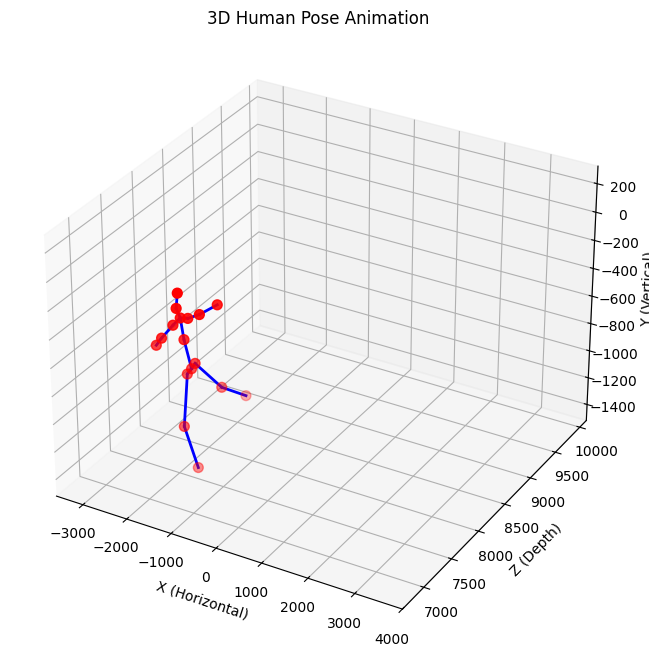

In [96]:
plot_3d(pred_data)

In [40]:
import os
import numpy as np
import json
from tqdm import tqdm

KEYPOINTS = [
    'Root', 'LHip', 'LKnee', 'LAnkle', 'RHip', 'RKnee', 'RAnkle',
    'Belly', 'Neck', 'Nose', 'Head', 
    'RShoulder', 'RElbow', 'RHand', 'LShoulder', 'LElbow', 'LHand'
]

def get_all_actors_and_cameras(root_dir):
    set_numbers = os.listdir(root_dir)
    actor_names = {n: dict() for n in set_numbers}
    for set_number in set_numbers:
        actor_paths = os.listdir(f"{root_dir}/{set_number}")
        for actor_path in actor_paths:
            if actor_path.split(".")[-1] != "json":
                continue
            actor_path = actor_path.split(".")[0]
            actor_name = "_".join(actor_path.split("_")[:-2])
            camera_name = "_".join(actor_path.split("_")[-2:])
            if actor_name in actor_names[set_number]:
                actor_names[set_number][actor_name].add(camera_name)
            else:
                actor_names[set_number][actor_name] = {camera_name}

    return actor_names

def get_overlap_frames(json_cam1, json_cam2):

    with open(json_cam1, 'r') as f:
        data_cam1 = json.load(f)
    with open(json_cam2, 'r') as f:
        data_cam2 = json.load(f)

    cam_1_start_frame = data_cam1['source_start_frame']
    cam_1_end_frame = data_cam1['source_end_frame']
    cam_2_start_frame = data_cam2['source_start_frame']
    cam_2_end_frame = data_cam2['source_end_frame']

    overlap_start = max(cam_1_start_frame, cam_2_start_frame)
    overlap_end = min(cam_1_end_frame, cam_2_end_frame)
    # print(f"Camera 1 frames: {cam_1_start_frame} to {cam_1_end_frame}")
    # print(f"Camera 2 frames: {cam_2_start_frame} to {cam_2_end_frame}")
    # print(f"Overlap frames: {overlap_start} to {overlap_end}")

    if overlap_start <= overlap_end:
        return overlap_start, overlap_end
    else:
        return -1, -1  # No overlap

def frame_mapping(data_cam1, data_cam2, frame_number):

    cam_1_start_frame = data_cam1['source_start_frame']
    cam_1_end_frame = data_cam1['source_end_frame']
    cam_2_start_frame = data_cam2['source_start_frame']
    cam_2_end_frame = data_cam2['source_end_frame']
    # print(f"Camera 1 frames: {cam_1_start_frame} to {cam_1_end_frame}")
    # print(f"Camera 2 frames: {cam_2_start_frame} to {cam_2_end_frame}")
    # print(f"Requested frame number: {frame_number}")

    if cam_1_start_frame <= frame_number <= cam_1_end_frame and cam_2_start_frame <= frame_number <= cam_2_end_frame:
        cam_1_frame_index = frame_number - cam_1_start_frame
        cam_2_frame_index = frame_number - cam_2_start_frame
        return cam_1_frame_index, cam_2_frame_index
    else:
        raise ValueError("Frame number is out of range for one or both cameras.")

def infront_of_camera(keypoints3d):
    """
    Determine if the person is facing towards the camera based on the 3D keypoints.
    
    Args:
        keypoints3d (dict): A dictionary containing 3D coordinates of keypoints.
    Returns:
        bool: True if the person is facing towards the camera, False otherwise.
    """

    root_points = ['RShoulder', 'LShoulder', 'RHip']
    rshoulder = keypoints3d.get('RShoulder')
    lshoulder = keypoints3d.get('LShoulder')
    rhip = keypoints3d.get('RHip')
    nose = keypoints3d.get('Nose')

    v1 = np.array(lshoulder) - np.array(rshoulder)
    v2 = np.array(rhip) - np.array(rshoulder)
    front_vector = np.cross(v2, v1)
    n = np.linalg.norm(front_vector)
    front_vector = front_vector / (n + 1e-8)

    store = {}
    for point in keypoints3d.keys():
        v = np.array(keypoints3d[point]) - np.array(nose)
        v = v / (np.linalg.norm(v) + 1e-8)
        d = float(np.dot(v, front_vector))
        if d < 0:
            store[point] = -1
        else:
            store[point] = 1
    
    for point in root_points:
        if point in store:
            store[point] = 1
    return store

def distance_to_other_keypoint(keypoints3d):
    """
    Calculate the distance from each keypoint to the camera (assumed to be at the origin).
    
    Args:
        keypoints3d (dict): A dictionary containing 3D coordinates of keypoints.
    Returns:
        dict: A dictionary with keypoints as keys and their distances to the camera as values.
    """
    distances = {}
    for point1, coords1 in keypoints3d.items():
        distances[point1] = []
        for point2, coords2 in keypoints3d.items():
            if point1 != point2:
                dist = np.linalg.norm(np.array(coords1) - np.array(coords2))
                distances[point1].append((dist))
    return distances

def calculate_component_difference(keypoints3d_cam1, keypoints3d_cam2, threshold=5):
    
    point_differences = {}
    for point in keypoints3d_cam1:
        num_diff = 0
        for i in range (len(keypoints3d_cam1[point])-1):
            a = keypoints3d_cam1[point][i]
            b = keypoints3d_cam2[point][i]
            n = 2 * abs(a - b) / (abs(a) + abs(b) + 1e-8) * 100
            if n > threshold:
                num_diff += 1
        point_differences[point] = num_diff
    return point_differences

def compare_keypoints(root_dir, set_number, actor_name, video_name_cam1, video_name_cam2, frame_number):

    data_cam1 = np.load(f'valid/{set_number}/{actor_name}_{video_name_cam1}.npy', allow_pickle=True)
    data_cam2 = np.load(f'valid/{set_number}/{actor_name}_{video_name_cam2}.npy', allow_pickle=True)
    
    cam_1_json_path = f'{root_dir}/{set_number}/{actor_name}_{video_name_cam1}.json'
    cam_2_json_path = f'{root_dir}/{set_number}/{actor_name}_{video_name_cam2}.json'

    with open(cam_1_json_path, 'r') as f:
        data_cam1_json = json.load(f)
    with open(cam_2_json_path, 'r') as f:
        data_cam2_json = json.load(f)
    

    frame_cam_1, frame_cam_2 = frame_mapping(data_cam1_json, data_cam2_json, frame_number)

    keypoints3d_cam1 = {}
    keypoints3d_cam2 = {}

    for keypoint, coords_cam1, coords_cam2 in zip(KEYPOINTS, data_cam1[frame_cam_1], data_cam2[frame_cam_2]):

        keypoints3d_cam1[keypoint] = coords_cam1.tolist()
        keypoints3d_cam2[keypoint] = coords_cam2.tolist()

    result_cam1 = infront_of_camera(keypoints3d_cam1)
    distances_cam1 = distance_to_other_keypoint(keypoints3d_cam1)
    result_cam2 = infront_of_camera(keypoints3d_cam2)
    distances_cam2 = distance_to_other_keypoint(keypoints3d_cam2)

    for point in keypoints3d_cam1.keys():
        distances_cam1[point].append(result_cam1[point])
        distances_cam2[point].append(result_cam2[point])
    
    # Compare direction of keypoints between the two cameras
    count = 0
    diff_direction = []
    for point in keypoints3d_cam1.keys():
        cam1_facing = distances_cam1[point][-1]
        cam2_facing = distances_cam2[point][-1]
        if cam1_facing != cam2_facing:
            diff_direction.append(point)
    
    print("Keypoints with different facing directions between the two cameras:")
    for point in diff_direction:
        print(f"{point}: Cam1 - {distances_cam1[point][-1]}, Cam2 - {distances_cam2[point][-1]}")

    diff_array = []
    for point in keypoints3d_cam1.keys():
        if point in diff_direction:
            continue
        diff_norm = np.linalg.norm(np.array(distances_cam1[point][:-1]) - np.array(distances_cam2[point][:-1]))
        diff_array.append(diff_norm)
    
    # print("Difference in distances to camera for each keypoint:")
    # for point, diff in zip(keypoints3d_cam1.keys(), diff_array):
    #     print(f"{point}: {diff}")
    
    # Print out keypoints with difference on the Q3 quartile
    q3 = np.percentile(diff_array, 75)
    # print(f"Keypoints with distance difference above the Q3 quartile ({q3}):")
    for point, diff in zip(keypoints3d_cam1.keys(), diff_array):
        if diff > q3:
            print(f"{point}: {diff}")
            count +=1
    count += len(diff_direction)
    # print(f"Total keypoints with significant differences: {count}")
    if count > 0:
        print(f"Actor: {actor_name}, Cam1: {video_name_cam1}, Cam2: {video_name_cam2}, Frame: {frame_number}, Significant Differences: {count}")

In [41]:
set_number = "S1"
actor_name = "Axel_10"
video_name_cam1 = "cam_1"
video_name_cam2 = "cam_5"
frame_number = 100
root_dir = f"/kaggle/input/datasets/minhducnguyen9705/athelete-pose-3d/dataset/dataset/data/valid_set"
# all_data = get_all_actors_and_cameras(root_dir)

# for set_number, actors in tqdm(all_data.items(), desc="Processing sets"):
#     # print(f"Set: {set_number}: {actors}")
#     for actor_name, cameras in tqdm(actors.items(), desc="Processing actors"):
#         for cam1 in cameras:
#             for cam2 in cameras:
#                 if cam1 != cam2:
#                     json_cam1 = os.path.join(root_dir, f"{set_number}/{actor_name}_{cam1}.json")
#                     json_cam2 = os.path.join(root_dir, f"{set_number}/{actor_name}_{cam2}.json")
#                     # print(f"Comparing {actor_name} between {cam1} and {cam2}")
#                     overlap_start, overlap_end = get_overlap_frames(json_cam1, json_cam2)
#                     if overlap_start != -1:
#                         # print(f"Comparing {actor_name} between {cam1} and {cam2} with overlapping frames from {overlap_start} to {overlap_end}")
#                         for frame_number in range(overlap_start, overlap_end + 1):
#                             # print(f"Comparing {actor_name} between {cam1} and {cam2} at frame {frame_number}")
#                             compare_keypoints(root_dir, set_number, actor_name, cam1, cam2, frame_number)

compare_keypoints(root_dir, set_number, actor_name, video_name_cam1, video_name_cam2, frame_number)

Keypoints with different facing directions between the two cameras:
RKnee: Cam1 - -1, Cam2 - 1
Head: Cam1 - 1, Cam2 - -1
RElbow: Cam1 - -1, Cam2 - 1
RHand: Cam1 - -1, Cam2 - 1
LElbow: Cam1 - -1, Cam2 - 1
LHand: Cam1 - -1, Cam2 - 1
Belly: 255.86799747956954
Nose: 302.4681052964527
Head: 479.8480997303284
Actor: Axel_10, Cam1: cam_1, Cam2: cam_5, Frame: 100, Significant Differences: 9


In [ ]:
!ls output/S1